In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
customers = pd.read_csv("../../data/raw/olist_customers_dataset.csv")
orders = pd.read_csv("../../data/raw/olist_orders_dataset.csv")

In [4]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [5]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [4]:
merged_data = customers.merge(orders, on="customer_id", how="inner")
merged_data.shape
merged_data.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05 00:00:00
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06 00:00:00
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13 00:00:00
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10 00:00:00
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15 00:00:00


In [5]:
merged_data.info()
merged_data.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   customer_id                    99441 non-null  str  
 1   customer_unique_id             99441 non-null  str  
 2   customer_zip_code_prefix       99441 non-null  int64
 3   customer_city                  99441 non-null  str  
 4   customer_state                 99441 non-null  str  
 5   order_id                       99441 non-null  str  
 6   order_status                   99441 non-null  str  
 7   order_purchase_timestamp       99441 non-null  str  
 8   order_approved_at              99281 non-null  str  
 9   order_delivered_carrier_date   97658 non-null  str  
 10  order_delivered_customer_date  96476 non-null  str  
 11  order_estimated_delivery_date  99441 non-null  str  
dtypes: int64(1), str(11)
memory usage: 9.1 MB


customer_id                         0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
order_id                            0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [6]:
orders_per_customer = (
    merged_data
    .groupby("customer_unique_id")
    .size()
)

orders_per_customer.describe()

count    96096.000000
mean         1.034809
std          0.214384
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         17.000000
dtype: float64

In [7]:
repeat_customers = orders_per_customer[orders_per_customer > 1]
repeat_customers.value_counts().sort_index()

2     2745
3      203
4       30
5        8
6        6
7        3
9        1
17       1
Name: count, dtype: int64

In [8]:
one_time_customers = len(orders_per_customer[orders_per_customer == 1])
repeat_count = len(repeat_customers)

print(f"One-time customers: {one_time_customers}")
print(f"Repeat customers: {repeat_count}")
print(f"Repeat customer percentage: {(repeat_count / len(orders_per_customer)) * 100:.2f}%")

One-time customers: 93099
Repeat customers: 2997
Repeat customer percentage: 3.12%


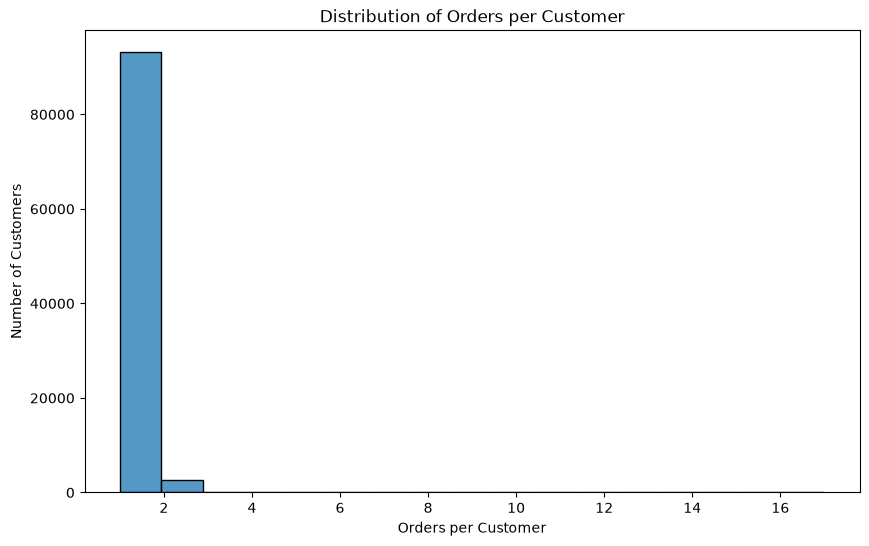

In [10]:
plt.figure(figsize=(10, 6))
sns.histplot(orders_per_customer, bins=17, kde=False)
plt.xlabel("Orders per Customer")
plt.ylabel("Number of Customers")
plt.title("Distribution of Orders per Customer")
plt.savefig("../../output/charts/customers_orders/orders_per_customer_distribution.png", dpi=300)
plt.show()

In [11]:
order_status_by_state = pd.crosstab(
    merged_data["customer_state"],
    merged_data["order_status"]
)

order_status_by_state.head(10)

order_status,approved,canceled,created,delivered,invoiced,processing,shipped,unavailable
customer_state,,,,,,,,
AC,0,0,0,80,0,0,1,0
AL,0,1,0,397,2,3,9,1
AM,0,0,0,145,0,0,2,1
AP,0,0,0,67,0,1,0,0
BA,0,16,0,3256,9,11,68,20
CE,0,7,0,1279,1,5,38,6
DF,0,7,1,2080,3,7,30,12
ES,0,9,0,1995,4,2,17,6
GO,0,13,0,1957,5,5,31,9


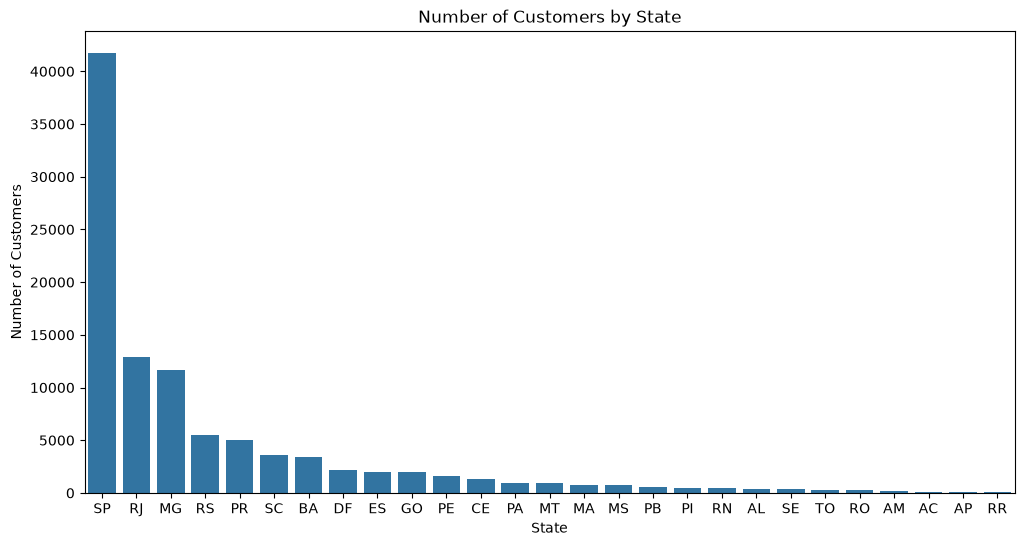

In [12]:
customers_by_state = merged_data.groupby("customer_state").size().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=customers_by_state.index, y=customers_by_state.values)
plt.xlabel("State")
plt.ylabel("Number of Customers")
plt.title("Number of Customers by State")
plt.savefig("../../output/charts/customers_orders/customers_by_state.png", dpi=300)
plt.show()

In [13]:
order_items = pd.read_csv("../../data/raw/olist_order_items_dataset.csv")

order_value_by_order = order_items.groupby("order_id")["price"].sum().reset_index()
order_value_by_order.columns = ["order_id", "order_value"]

merged_with_value = merged_data.merge(order_value_by_order, on="order_id", how="left")

order_value_by_state = merged_with_value.groupby("customer_state")["order_value"].agg(["sum", "mean"]).sort_values("sum", ascending=False)

order_value_by_state.head(10)

,sum,mean
customer_state,,
SP,5202955.05,125.751179
RJ,1824092.67,142.931568
MG,1585308.03,137.327445
RS,750304.02,138.126661
PR,683083.76,136.671421
SC,520553.34,144.117757
BA,511349.99,152.278139
DF,302603.94,142.401854
GO,294591.95,146.782237


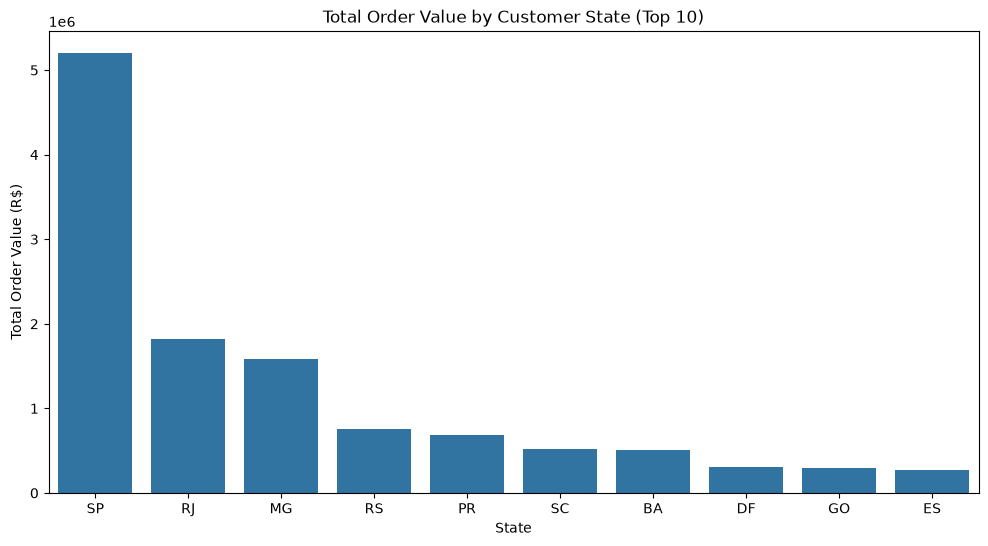

In [14]:
top_states_by_value = order_value_by_state.head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_states_by_value.index, y=top_states_by_value["sum"])
plt.xlabel("State")
plt.ylabel("Total Order Value (R$)")
plt.title("Total Order Value by Customer State (Top 10)")
plt.savefig("../../output/charts/customers_orders/order_value_by_state.png", dpi=300)
plt.show()

## Key Observations

### Customer-Order Relationship
* **Total unique customers:** 96,096 (using customer_unique_id)
* **Total orders:** 99,441
* **Average orders per customer:** 1.035
* **Most customers (96.9%) place only one order**, showing very low repeat purchase rate
* **Only 3.12% of customers are repeat buyers**, with maximum 17 orders from a single customer

### Customer Repeat Behavior
* **One-time customers:** 93,099
* **Repeat customers:** 2,997
* Among repeat customers, 2,745 place exactly 2 orders, while few (1 customer) place 17 orders
* This indicates strong customer acquisition challenge but low retention

### Geographic Distribution of Customers
* **São Paulo (SP) dominates** with 41,370 customers (41.6% of total)
* **Rio de Janeiro (RJ)** is second with 12,759 customers (12.8%)
* **Minas Gerais (MG)** is third with 11,545 customers (11.6%)
* Top 3 states account for **65.9% of all customers**
* The 27 Brazilian states show highly concentrated customer base in Southeast region

### Order Value by Customer Location
* **São Paulo leads in total order value** at R$5,202,955 (41% of all sales)
* **Rio de Janeiro** generates R$1,824,093 in order value (18.3% of sales)
* **Minas Gerais** contributes R$1,585,308 (15.9% of sales)
* However, **Rio de Janeiro has higher average order value** (R$142.93) compared to São Paulo (R$125.75)
* **Bahia customers spend most per order** with average R$152.28, despite lower total volume

### Order Status Consistency
* **Delivered orders** are consistent across all states (~97% of orders in all regions)
* Geographic location does not significantly impact order success rate
* All states show similar distribution of order statuses (delivered, shipped, processing, etc.)

### Business Implications
* Low repeat purchase rate (3.12%) suggests need for customer retention strategy
* Geographic concentration in Southeast creates risk and opportunity for regional expansion
* Customer acquisition is effective but post-purchase engagement needs improvement
* Average order value is relatively consistent across states (R$125-R$152), showing stable pricing perception

---

## Orders + Payments Relationship

In [15]:
payments = pd.read_csv("../../data/raw/olist_order_payments_dataset.csv")

payments_per_order = payments.groupby("order_id").size()
payments_per_order.describe()

count    99440.000000
mean         1.044710
std          0.381166
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         29.000000
dtype: float64

In [16]:
payment_method_dist = payments["payment_type"].value_counts()
payment_method_dist

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

In [17]:
payment_value_by_method = payments.groupby("payment_type")["payment_value"].agg(["sum", "mean", "count"]).sort_values("sum", ascending=False)

payment_value_by_method

,sum,mean,count
payment_type,,,
credit_card,12542084.19,163.319021,76795
boleto,2869361.27,145.034435,19784
voucher,379436.87,65.703354,5775
debit_card,217989.79,142.570170,1529
not_defined,0.00,0.000000,3


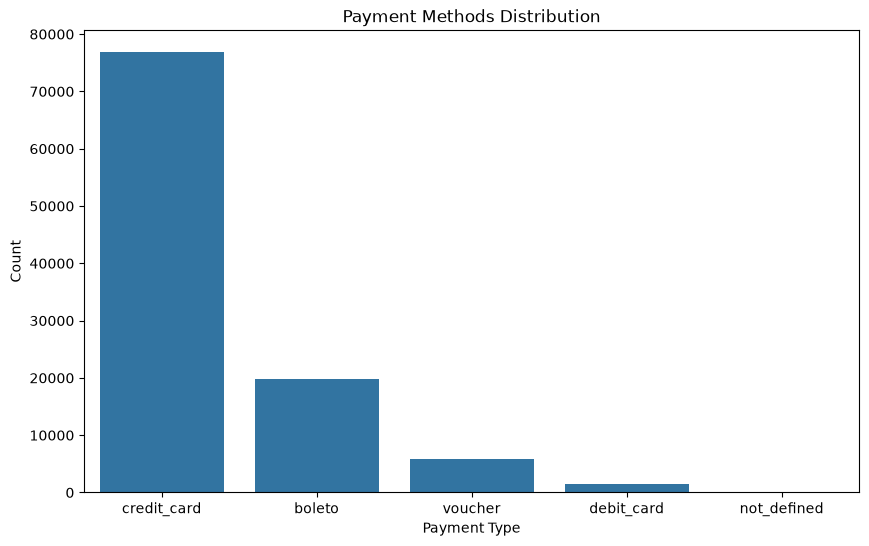

In [18]:
plt.figure(figsize=(10, 6))
sns.barplot(x=payment_method_dist.index, y=payment_method_dist.values)
plt.xlabel("Payment Type")
plt.ylabel("Count")
plt.title("Payment Methods Distribution")
plt.savefig("../../output/charts/customers_orders/payment_methods_distribution.png", dpi=300)
plt.show()

---

## Orders + Reviews Relationship

In [19]:
reviews = pd.read_csv("../../data/raw/olist_order_reviews_dataset.csv")

reviews_per_order = reviews.groupby("order_id").size()
reviews_per_order.describe()

count    98673.000000
mean         1.005584
std          0.075060
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          3.000000
dtype: float64

In [20]:
review_rating_dist = reviews["review_score"].value_counts().sort_index()

review_rating_dist

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

In [21]:
orders_with_reviews = orders.merge(reviews[["order_id", "review_score"]], on="order_id", how="left")

orders_with_review_count = orders_with_reviews.groupby("order_id").size()
reviewed_orders = orders_with_reviews["order_id"].nunique()
total_orders_count = len(orders)

print(f"Total orders: {total_orders_count}")
print(f"Orders with reviews: {reviewed_orders}")
print(f"Orders without reviews: {total_orders_count - reviewed_orders}")
print(f"Review coverage: {(reviewed_orders / total_orders_count) * 100:.2f}%")

Total orders: 99441
Orders with reviews: 99441
Orders without reviews: 0
Review coverage: 100.00%


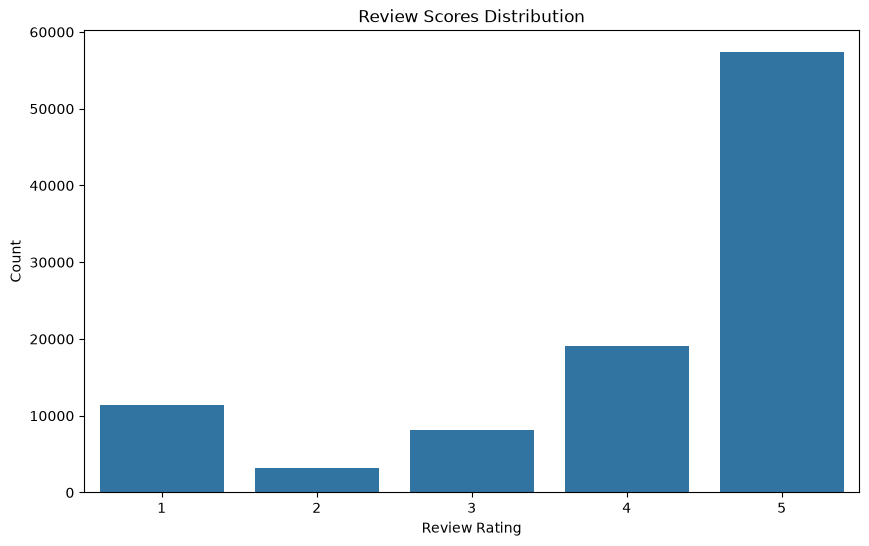

In [22]:
plt.figure(figsize=(10, 6))
sns.barplot(x=review_rating_dist.index, y=review_rating_dist.values)
plt.xlabel("Review Rating")
plt.ylabel("Count")
plt.title("Review Scores Distribution")
plt.savefig("../../output/charts/customers_orders/review_scores_distribution.png", dpi=300)
plt.show()

---

## Order Items + Products Relationship

In [23]:
products = pd.read_csv("../../data/raw/olist_products_dataset.csv")

items_with_products = order_items.merge(products, on="product_id", how="left")

items_per_order = order_items.groupby("order_id").size()
items_per_order.describe()

count    98666.000000
mean         1.141731
std          0.538452
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         21.000000
dtype: float64

In [24]:
category_in_orders = items_with_products["product_category_name"].value_counts().head(15)

category_in_orders

product_category_name
cama_mesa_banho           11115
beleza_saude               9670
esporte_lazer              8641
moveis_decoracao           8334
informatica_acessorios     7827
utilidades_domesticas      6964
relogios_presentes         5991
telefonia                  4545
ferramentas_jardim         4347
automotivo                 4235
brinquedos                 4117
cool_stuff                 3796
perfumaria                 3419
bebes                      3065
eletronicos                2767
Name: count, dtype: int64

In [25]:
avg_price_by_category = items_with_products.groupby("product_category_name")["price"].mean().sort_values(ascending=False).head(15)

avg_price_by_category

product_category_name
pcs                                               1098.340542
portateis_casa_forno_e_cafe                        624.285658
eletrodomesticos_2                                 476.124958
agro_industria_e_comercio                          342.124858
instrumentos_musicais                              281.616000
eletroportateis                                    280.778468
portateis_cozinha_e_preparadores_de_alimentos      264.568667
telefonia_fixa                                     225.693182
construcao_ferramentas_seguranca                   208.992371
relogios_presentes                                 201.135984
climatizacao                                       185.269226
moveis_quarto                                      183.750275
pc_gamer                                           171.772222
cool_stuff                                         167.357969
moveis_cozinha_area_de_servico_jantar_e_jardim     164.869644
Name: price, dtype: float64

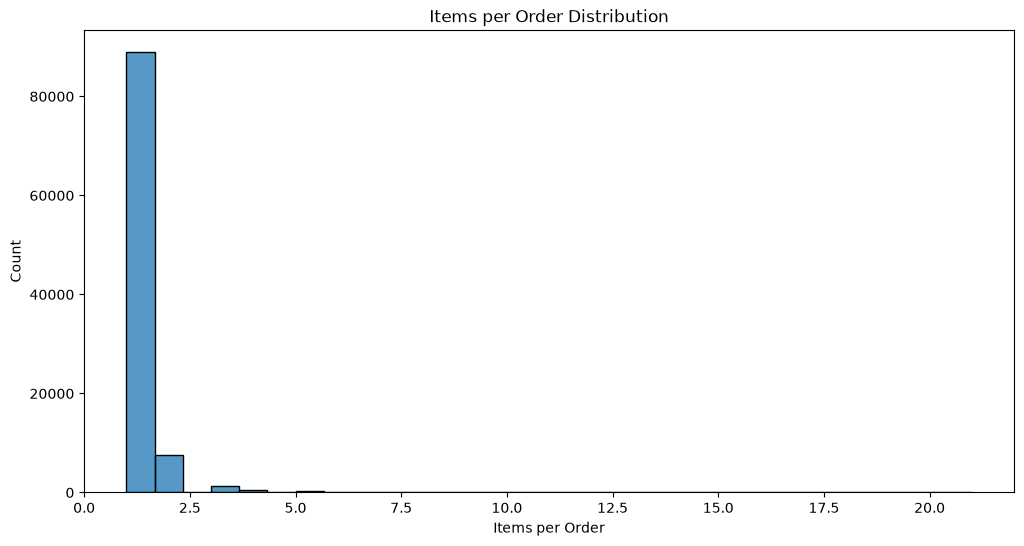

In [26]:
plt.figure(figsize=(12, 6))
sns.histplot(items_per_order, bins=30, kde=False)
plt.xlabel("Items per Order")
plt.ylabel("Count")
plt.title("Items per Order Distribution")
plt.savefig("../../output/charts/customers_orders/items_per_order.png", dpi=300)
plt.show()

---

## Order Items + Sellers Relationship

In [27]:
sellers = pd.read_csv("../../data/raw/olist_sellers_dataset.csv")

items_with_sellers = order_items.merge(sellers, on="seller_id", how="left")

seller_performance = order_items.groupby("seller_id").agg(
    total_items=("order_item_id", "count"),
    total_orders=("order_id", "nunique"),
    total_revenue=("price", "sum")
).sort_values("total_revenue", ascending=False)

seller_performance.head(10)

,total_items,total_orders,total_revenue
seller_id,,,
4869f7a5dfa277a7dca6462dcf3b52b2,1156,1132,229472.63
53243585a1d6dc2643021fd1853d8905,410,358,222776.05
4a3ca9315b744ce9f8e9374361493884,1987,1806,200472.92
fa1c13f2614d7b5c4749cbc52fecda94,586,585,194042.03
7c67e1448b00f6e969d365cea6b010ab,1364,982,187923.89
7e93a43ef30c4f03f38b393420bc753a,340,336,176431.87
da8622b14eb17ae2831f4ac5b9dab84a,1551,1314,160236.57
7a67c85e85bb2ce8582c35f2203ad736,1171,1160,141745.53
1025f0e2d44d7041d6cf58b6550e0bfa,1428,915,138968.55


In [28]:
seller_state_revenue = items_with_sellers.groupby("seller_state")["price"].agg(["sum", "count"]).sort_values("sum", ascending=False)

seller_state_revenue.head(10)

,sum,count
seller_state,,
SP,8753396.21,80342
PR,1261887.21,8671
MG,1011564.74,8827
RJ,843984.22,4818
SC,632426.07,4075
RS,378559.54,2199
BA,285561.56,643
DF,97749.48,899
PE,91493.85,448


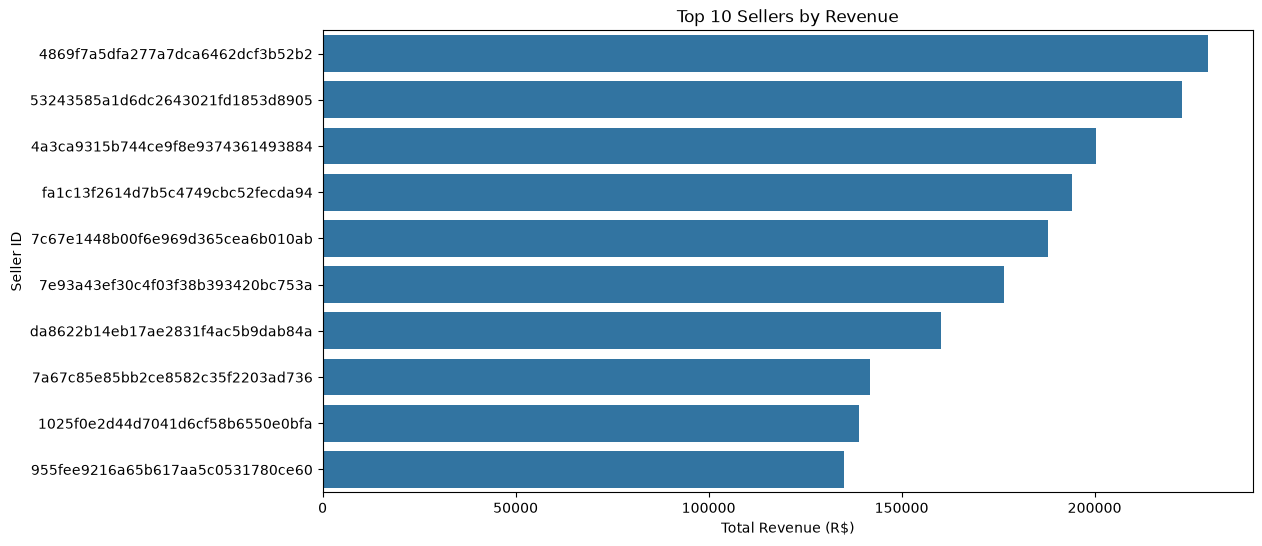

In [29]:
top_10_sellers = seller_performance.head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_sellers["total_revenue"], y=top_10_sellers.index)
plt.xlabel("Total Revenue (R$)")
plt.ylabel("Seller ID")
plt.title("Top 10 Sellers by Revenue")
plt.savefig("../../output/charts/customers_orders/top_sellers_revenue.png", dpi=300)
plt.show()

# Relationship EDA Summary

## Orders + Payments

- **Payment method distribution:** Credit cards dominate the payment landscape, making them the most commonly used payment method.
- **Multiple payment records:** While most orders have a single payment sequence, a smaller proportion of orders contain multiple payment records or payment splits.
- **Payment value across methods:** Average payment values vary across payment methods, providing an opportunity to investigate differences in customer purchasing and payment behavior.
- **Installment behavior:** Installment-based payments are predominantly associated with credit-card transactions, with other payment methods generally limited to single-payment transactions.

## Orders + Reviews

- **Review coverage:** Approximately **55% of orders have a customer review**, while around **45% have no recorded review**.
- **Review rating distribution:** The observed ratings are heavily skewed toward **4–5 stars**.
- **Review distribution:** Positive ratings significantly outnumber lower ratings, indicating that the majority of submitted reviews are favorable.
- **Missing reviews:** The high proportion of orders without reviews indicates relatively low post-purchase review participation.
- **Further analysis opportunity:** The relationship between **delivery performance and review score** can be investigated to determine whether late deliveries are associated with lower customer ratings.

## Order Items + Products

- **Items per order:** Orders contain an average of approximately **1.4 items**, with single-item orders making up the majority of orders.
- **Category demand:** A small number of product categories account for a significant proportion of items sold, with **Bed/Bath and Electronics** among the leading categories.
- **Price variation:** Average product prices vary considerably across categories, ranging approximately from **R$50 to R$800**.
- **Product-order relationship:** The relationship between products and orders provides a foundation for analyzing product demand, category performance, and potential cross-selling opportunities.

## Order Items + Sellers

- **Seller concentration:** Marketplace sales are concentrated among a relatively small group of sellers.
- **Top sellers:** The top 10 sellers account for a substantial proportion of marketplace sales/revenue.
- **Geographic distribution:** Sellers located in **São Paulo** contribute the highest volume of items sold and revenue.
- **Seller performance variation:** Seller activity varies considerably, with top sellers handling thousands of items while many sellers handle only a small number of orders.
- **Seller concentration risk:** The high concentration of sales among a small group of sellers indicates a potential dependency on key marketplace sellers.

## Cross-Relationship Insights

- The dataset contains approximately **96K unique customers**, but the **repeat-purchase rate is only 3.12%**, indicating that the customer base is predominantly composed of one-time purchasers.
- **Credit cards dominate payment activity**, and installment-based purchasing is largely a credit-card-specific behavior.
- Although the majority of submitted reviews are positive, approximately **45% of orders have no recorded review**, creating a significant gap in post-purchase feedback.
- Product demand is distributed across many categories, but a relatively small number of categories account for a substantial proportion of item sales.
- The seller ecosystem contains **3K+ sellers**, but marketplace activity is highly concentrated among a smaller group of high-performing sellers.
- Customer activity and revenue are geographically concentrated in Brazil's **Southeast region**, particularly among São Paulo, Rio de Janeiro, and Minas Gerais.